# Examen Titanic

En esta prueba usaremos un algoritmo de prediccion para en base a un dataset sobre la inundacion del Titanic y poder predecir si el 
usuario pudo sobrevivir a la inundacion.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score,fbeta_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import mode


In [2]:
def load_data_local(ubicacion):
    try:
        df = pd.read_csv(ubicacion)
        return df
    except Exception as e:
        print(f"Error al cargar la B.D.: {e}")
        return None

In [3]:
dataSet_original = load_data_local('./Data/titanic.csv')
dataSet_original.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## PreAnalis de los Datos
    1.- Descartamos columnas que no sean de utilidad al modelo o que puedan sesgar en la toma de decision
    2.- Imputamos datos que hagan faltas en las columnas a utilizar
    3.- Guardamos una copia de esos datos ya imputados.
    4.- Codificamos y normalizamos los datos para el entrenamiento del modelo.


In [4]:
def imputacion_knn(data_list, k=5):
    data_imputada = []
    # cambios = []  # Lista para la auditoría
    
    for i, x in enumerate(data_list):
        if pd.isna(x):
            vecinos = []
            # Buscar vecinos a la izquierda
            for j in range(i-1, max(i-k-1, -1), -1):
                if not pd.isna(data_list[j]):
                    vecinos.append(data_list[j])
                if len(vecinos) >= k:
                    break
            
            # Buscar vecinos a la derecha
            for j in range(i+1, min(i+k+1, len(data_list))):
                if not pd.isna(data_list[j]):
                    vecinos.append(data_list[j])
                if len(vecinos) >= k:
                    break
            
            if vecinos:
                nuevo_valor = sum(vecinos) / len(vecinos)
                data_imputada.append(nuevo_valor)
            else:
                data_imputada.append(x)  # Se queda como NaN si no hubo vecinos
        else:
            data_imputada.append(x)
            
    return data_imputada


In [5]:
#Funcion para obtencion de maximo de la columna #
def get_max_value(values):
    max_val = None
    # if(len(values) > 0):
    for p in values:
        if max_val is None or (isinstance(p,(int,float)) and p > max_val):
            max_val = p
    return max_val

#Funcion para obtencion de minimos de la columna#
def get_min_value(values): 
    min_value = None
    # if(len(values) > 0):
    for p in values:
        if min_value is None or (isinstance(p,(int,float)) and p < min_value):
            min_value = p
    return min_value


In [6]:
# Codificacion
def codificacion_one_hot(data_list):
    categorias = sorted(set(x for x in data_list if str(x).lower() != 'nan'))
    codificacion = {cat: [1 if x == cat else 0 for x in data_list] for cat in categorias}
    return codificacion

# Normalizacion
def normalizacion_min_max(data_list):
    min_val = get_min_value(data_list)
    max_val = get_max_value(data_list)
    if max_val == min_val:
        return [0.5 for _ in data_list]  # Evitar división por cero, asignamos 0.5 a todos
    return [(x - min_val) / (max_val - min_val) if not pd.isna(x) else x for x in data_list]

### Unicamente guardamos las columnas que nos seran de utilidad para el modelo y realizamos imputacion

In [7]:
# --- 1. Preparación previa de los datos ---
dataset_Copia = dataSet_original[["survived","pclass","sex","age","sibsp","parch","embarked"]].copy()

dataset_Copia['sex'] = dataset_Copia['sex'].map({'male': 1, 'female': 0})

dataset_Copia['age'] = imputacion_knn(dataset_Copia['age'], 5)
dataset_Copia['age'] = dataset_Copia['age'].round(0).astype(int)

dataset_Copia['embarked'] = dataset_Copia['embarked'].map({'S': 0, 'C': 1, 'Q': 2})
dataset_Copia['embarked'] = np.ceil(imputacion_knn(dataset_Copia['embarked'], 3)).astype(int)

In [9]:
# # --- 2. Crear la Visualización ---
# plt.figure(figsize=(10, 6)) # Un poco más ancha para que se aprecie mejor

# # Graficamos la Original (usamos dropna() para evitar errores)
# # Usamos un color azul y alpha bajo para la transparencia
# sns.kdeplot(dataset_Copia['age'].dropna(), 
#             fill=True, 
#             color="#3498db", # Azul
#             alpha=0.4, 
#             linewidth=2.5, 
#             label='Original (con Nulos)')

# # Graficamos la Imputada en la MISMA gráfica
# # Usamos un color rojo/naranja y alpha similar
# sns.kdeplot(dataset_Copia['age_imputed'], 
#             fill=True, 
#             color="#e74c3c", # Rojo
#             alpha=0.4, 
#             linewidth=2.5, 
#             label=f'Imputada')


# # --- 3. Estilizado y Etiquetas ---
# plt.title('Comparación de Distribuciones de Edad: Antes y Después de Imputar')
# plt.xlabel('Edad')
# plt.ylabel('Densidad (Frecuencia relativa)')

# # ¡Importante! Activar la leyenda para saber qué color es cuál
# plt.legend()

# # Opcional: añadir una cuadrícula ligera de fondo
# plt.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.show()
# dataset_Copia.head()

### Guardamos una copia de los Datos

In [79]:
dataset_Copia.to_csv('./Data/titanic_copia.csv', index=False)

### Codificamos y normalizamos los valores para poder entrenar el modelo

In [8]:
# --- 2. Aplicar tu función de One-Hot a 'embarked' ---
dataset_Normalizado = dataset_Copia.copy()

# Convertimos la columna a lista para tu función
lista_embarked = dataset_Normalizado['embarked'].tolist()
dict_codificado = codificacion_one_hot(lista_embarked)

# Creamos las nuevas columnas en el DataFrame
# Esto creará columnas como 'embarked_0', 'embarked_1', 'embarked_2'
for categoria, valores in dict_codificado.items():
    dataset_Normalizado[f'embarked_{categoria}'] = valores

# --- 3. Aplicar a 'pclass'---
lista_pclass = dataset_Normalizado['pclass'].tolist()
dict_pclass = codificacion_one_hot(lista_pclass)

for categoria, valores in dict_pclass.items():
    dataset_Normalizado[f'pclass_{categoria}'] = valores

# --- 4. Limpieza Final ---
dataset_Normalizado.drop(columns=['embarked', 'pclass'], inplace=True)
dataset_Normalizado['age'] = normalizacion_min_max(dataset_Normalizado['age'].tolist())
dataset_Normalizado['sibsp'] = normalizacion_min_max(dataset_Normalizado['sibsp'].tolist())
dataset_Normalizado['parch'] = normalizacion_min_max(dataset_Normalizado['parch'].tolist())

## Entrenamiento del modelo KNN Classifier

Ahora que tenemos los datos que seran necesarios, descartando variables filtrantes que puedan afectar a la salida. Utilizaremos el modelo KNN Classifier para observar como se 
ven los datos y como actuan para tomar la decision

In [9]:
class KNeighbors_Classifier():
    def __init__(self, k):
        self.k = k
        
    def fit(self, X_train, Y_train):
        self.X_train = X_train
        self.Y_train = Y_train
        self.m, self.n = X_train.shape
        
    def predict(self, X_test):
        m_test = X_test.shape[0]
        Y_predict = np.zeros(m_test)
        for i in range(m_test):

            neighbors_labels = self.find_neighbors(X_test[i])
            
            m = mode(neighbors_labels, keepdims=True)
            Y_predict[i] = m.mode.flatten()[0]
        
        return Y_predict

    def find_neighbors(self, x):
        euclidean_distances = np.zeros(self.m)
        for i in range(self.m):
            d = self.euclidean(x, self.X_train[i])
            euclidean_distances[i] = d
        
        inds = euclidean_distances.argsort()
        # Ordenamos las etiquetas de entrenamiento según las distancias
        Y_train_sorted = self.Y_train[inds]
        return Y_train_sorted[:self.k]

    def euclidean(self, x, x_train):
        return np.sqrt(np.sum(np.square(x - x_train)))

Posteriormente entrenamos nuestro  modelo para poder observar sus aprendizajes mediante diferentes Vecinos para obtener el Mejor K (numero de vecinos)

In [10]:
def separar_datos(df, objetivo, test_size=0.2, random_state=42):
    # Definir una semilla para que los resultados sean reproducibles
    np.random.seed(random_state)
    
    # Mezclar los índices del DataFrame
    indices = df.index.tolist()
    np.random.shuffle(indices)
    
    # Calcular cuántos datos van para test
    tamano_test = int(len(df) * test_size)
    
    # Dividir los índices
    indices_test = indices[:tamano_test]
    indices_train = indices[tamano_test:]
    
    # Crear los sets de entrenamiento y prueba
    train_df = df.loc[indices_train]
    test_df = df.loc[indices_test]
    
    # Separar en X (características) y Y (lo que queremos predecir)
    # .values lo convierte a matrices de NumPy para tu clase KNN
    X_train = train_df.drop(columns=[objetivo]).values
    Y_train = train_df[objetivo].values
    X_test = test_df.drop(columns=[objetivo]).values
    Y_test = test_df[objetivo].values
    
    return X_train, X_test, Y_train, Y_test,indices_test

### Observacion del K optimo para el modelo

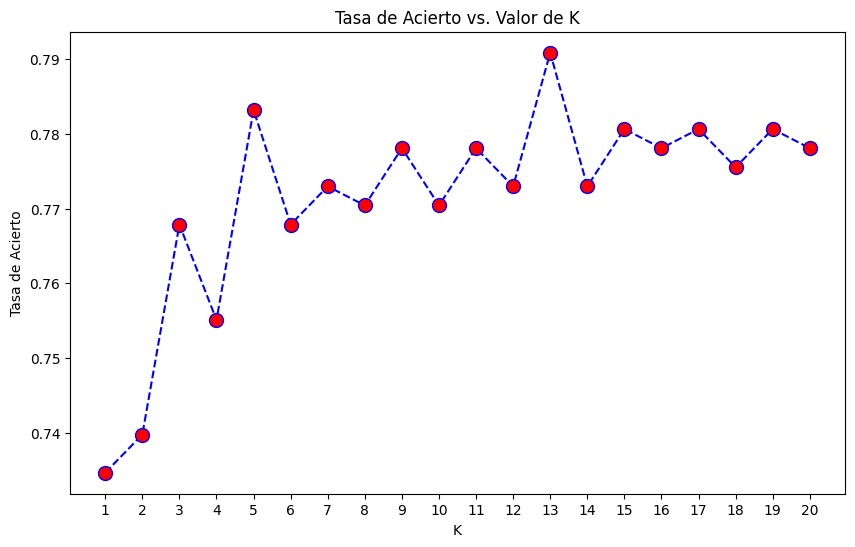

In [12]:
X_train, X_test, Y_train, Y_test, X_test_indices = separar_datos(dataset_Normalizado, 'survived', test_size=0.3, random_state=42)

acierto_rate = []
# Probamos valores de k desde 1 hasta 20
range_used = range(1, 21)

for i in range_used:
    knn = KNeighbors_Classifier(k=i)
    knn.fit(X_train, Y_train)
    pred_i = knn.predict(X_test)
    acierto_rate.append(np.mean(pred_i == Y_test))

# Graficamos los resultados
plt.figure(figsize=(10,6))
plt.plot(range_used, acierto_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)

# ESTA ES LA LÍNEA CLAVE:
plt.xticks(range_used) 
plt.title('Tasa de Acierto vs. Valor de K')
plt.xlabel('K')
plt.ylabel('Tasa de Acierto')
plt.show()

### Uso del K optimo

In [13]:
#Prueba con k=13
knn1 = KNeighbors_Classifier(k=5)
knn1.fit(X_train, Y_train)
pred_i1 = knn1.predict(X_test)
# print(f"Predicciones: {pred_i}")
# print(f"Valores Reales: {Y_test}")
print(f"Tasa de Acierto para k=5: {np.mean(pred_i1  == Y_test)}")

Tasa de Acierto para k=5: 0.7831632653061225


## Evaluacion de rendimiento del modelo

In [14]:
def graficar_datos_reales(df_original, test_indices, col_x, col_y):
    # 1. Configuración de estilo
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 8))
    
    # 2. Extraer y preparar datos
    df_real = df_original.iloc[test_indices].copy()
    
    # Definimos los nombres estándar
    label_vive = 'Sobrevivió'
    label_muere = 'No Sobrevivió'
    
    # Traducimos la realidad
    df_real['Estado Real'] = df_real['survived'].map({1: label_vive, 0: label_muere})
    
    # Diccionario de orden y traducción para los ejes
    orden_categorias = None
    if col_x == 'pclass':
        df_real['pclass'] = df_real['pclass'].map({1: '1ra Clase', 2: '2da Clase', 3: '3ra Clase'})
        orden_categorias = ['1ra Clase', '2da Clase', '3ra Clase']
    elif col_x == 'sex':
        df_real['sex'] = df_real['sex'].map({0: 'Mujer', 1: 'Hombre'})
        orden_categorias = ['Mujer', 'Hombre']

    # 3. Gráfica de nubes (Stripplot) corregida
    sns.stripplot(
        data=df_real,
        x=col_x,
        y=col_y,
        hue='Estado Real',
        order=orden_categorias,
        # Ahora las llaves coinciden exactamente con las etiquetas
        palette={label_vive: '#2ecc71', label_muere: '#e74c3c'},
        jitter=0.3,
        alpha=0.6,
        size=8,
        dodge=True
    )

    # 4. Títulos y estética
    plt.title(f'Datos Históricos Reales: {col_x.upper()} vs {col_y.upper()}', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel(f'{col_x.capitalize()}', fontsize=12)
    plt.ylabel(f'{col_y.capitalize()}', fontsize=12)
    
    plt.legend(title='Realidad Histórica', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

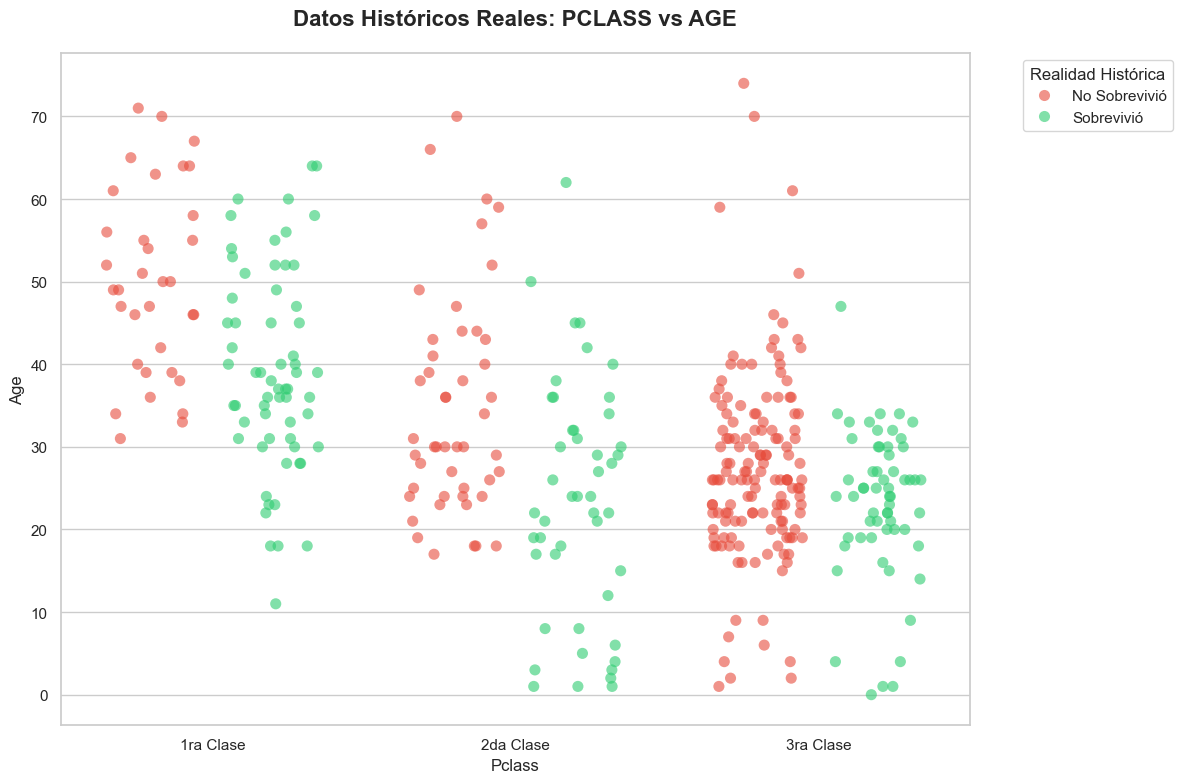

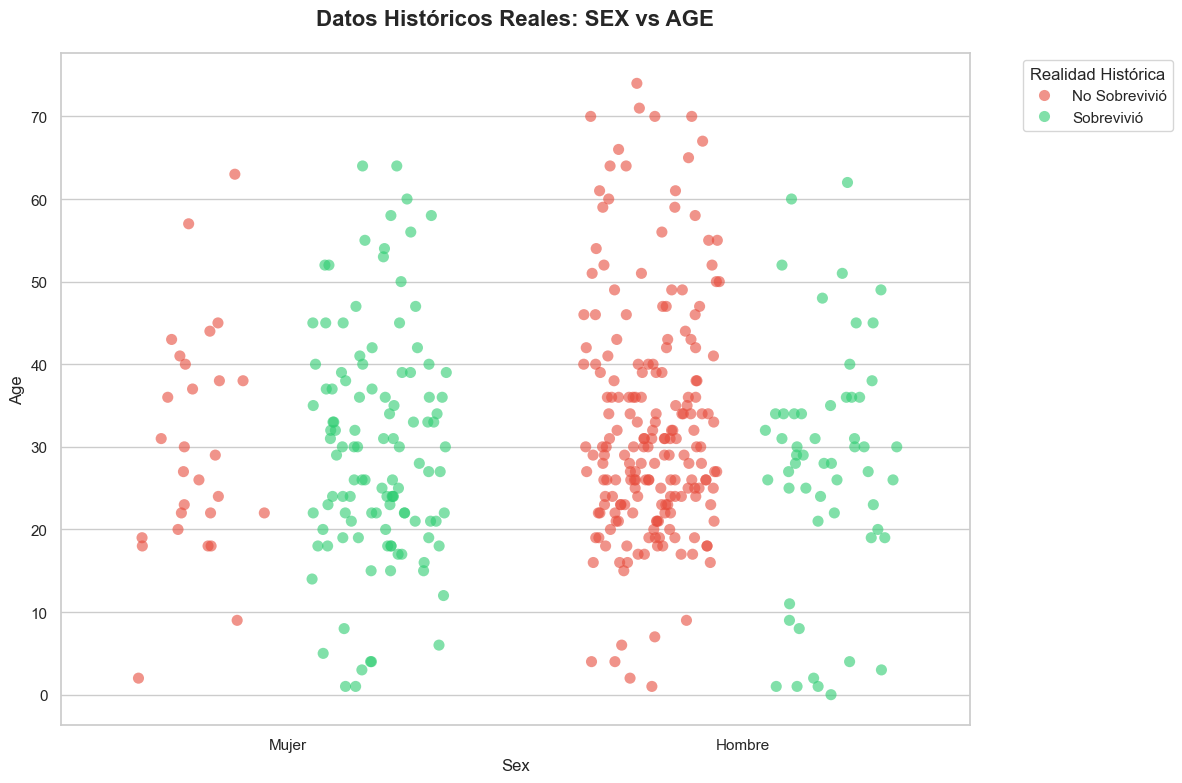

In [15]:
graficar_datos_reales(dataset_Copia, X_test_indices, 'pclass', 'age')
graficar_datos_reales(dataset_Copia, X_test_indices,'sex','age')

In [16]:
# Graficaremos un diagrama de confusion para observarlo de la mejor manera
def calcular_matriz_confusion(y_real, y_pred):
    # En el Titanic: 0 = Murió, 1 = Sobrevivió
    matriz = np.zeros((2, 2))
    
    for i in range(len(y_real)):
        fila = int(y_real[i])      # Valor real (Eje Y)
        columna = int(y_pred[i])   # Predicción (Eje X)
        matriz[fila][columna] += 1
        
    return matriz

def graficar_matriz(matriz, clases=['Murió', 'Sobrevivió']):
    plt.figure(figsize=(8, 6))
    plt.imshow(matriz, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Matriz de Confusión (Titanic)')
    plt.colorbar()
    
    # Configurar los ejes
    ticks = np.arange(len(clases))
    plt.xticks(ticks, clases)
    plt.yticks(ticks, clases)
    
    # Añadir los números en los cuadros
    umbral = matriz.max() / 2.
    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            plt.text(j, i, int(matriz[i, j]), horizontalalignment="center",  color="white" if matriz[i, j] > umbral else "black", fontsize=14)
            
    plt.ylabel('Realidad')
    plt.xlabel('Predicción del Modelo')
    plt.tight_layout()
    plt.show()

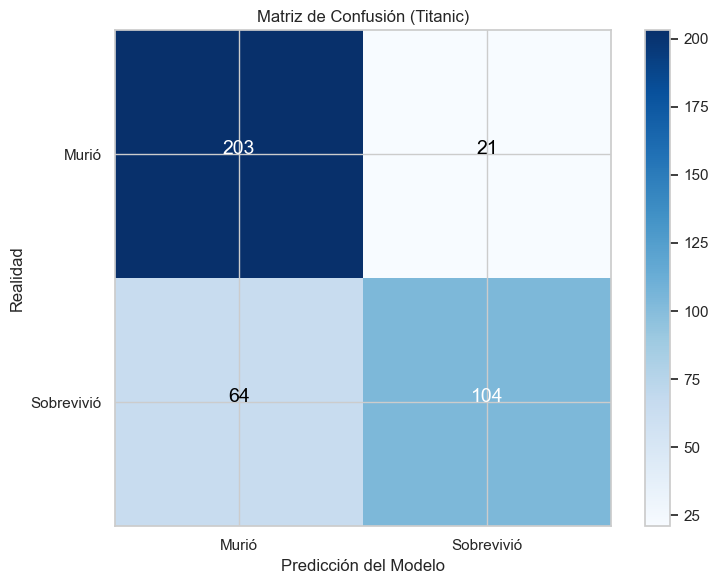

In [17]:
mi_matriz = calcular_matriz_confusion(Y_test, pred_i1)
graficar_matriz(mi_matriz)

In [89]:
def mostrar_comparativa(X_test, Y_test, Y_pred, n_muestras=10):
    # Creamos un DataFrame con los datos de prueba
    # Nota: Si X_test está escalado, podrías preferir usar los valores originales para leerlo mejor
    df_comparar = pd.DataFrame(X_test[:n_muestras])
    
    df_comparar['Real (Sobrevivió)'] = Y_test[:n_muestras]
    df_comparar['Predicción'] = Y_pred[:n_muestras].astype(int)
    
    # Añadimos una columna para ver si acertó
    df_comparar['¿Acertó?'] = df_comparar['Real (Sobrevivió)'] == df_comparar['Predicción']
    
    return df_comparar

In [18]:
# mostrar_comparativa(X_test, Y_test, pred_i1, n_muestras=50)

In [19]:
def reporte_clasificacion(matriz):
    tn, fp, fn, tp = matriz.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"--- Reporte de Clasificación ---")
    print(f"Precisión (¿Qué tan confiable es cuando dice que vive?): {precision:.2f}")
    print(f"Recall (¿Qué porcentaje de sobrevivientes detectó?): {recall:.2f}")
    print(f"F1-Score (Balance entre ambos): {f1:.2f}")

In [20]:
reporte_clasificacion(mi_matriz)

--- Reporte de Clasificación ---
Precisión (¿Qué tan confiable es cuando dice que vive?): 0.83
Recall (¿Qué porcentaje de sobrevivientes detectó?): 0.62
F1-Score (Balance entre ambos): 0.71


In [47]:
def graficar_seaborn(df_original, test_indices, Y_pred, col_x, col_y):
    # 1. Configuración de estilo
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 8))
    
    # 2. Preparar datos
    df_plot = df_original.iloc[test_indices].copy()
    df_plot['Veredicto'] = ["Sobrevive" if p == 1 else "No Sobrevive" for p in Y_pred]
    
    # Diccionario de traducción
    traducciones = {
        'sex': {0: 'Mujer', 1: 'Hombre'},
        'pclass': {1: '1ra Clase', 2: '2da Clase', 3: '3ra Clase'}
    }
    
    # Definir el orden manual para que no salga 3, 1, 2
    # Si la columna es pclass, forzamos este orden específico:
    orden_manual = None
    if col_y == 'pclass':
        orden_manual = ['1ra Clase', '2da Clase', '3ra Clase']
    elif col_y == 'sex':
        orden_manual = ['Mujer', 'Hombre']

    # Aplicar traducción si existe
    for col in [col_x, col_y]:
        if col in traducciones:
            df_plot[col] = df_plot[col].map(traducciones[col])

    # 3. Gráfico con el parámetro 'order'
    sns.stripplot(
        data=df_plot,
        x=col_x,
        y=col_y,
        hue='Veredicto',
        order=orden_manual,  # <--- AQUÍ se corrige el orden 1, 2, 3
        palette={'Sobrevive': '#2ecc71', 'No Sobrevive': '#e74c3c'},
        jitter=0.3,
        alpha=0.6,
        size=8,
        dodge=True
    )

    # 4. Títulos dinámicos
    plt.title(f'Predicciones del Modelo: {col_x.upper()} vs {col_y.upper()}', fontsize=16, pad=20)
    plt.xlabel(col_x.capitalize(), fontsize=12)
    plt.ylabel(col_y.capitalize(), fontsize=12)
    
    plt.legend(title='Resultado KNN', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

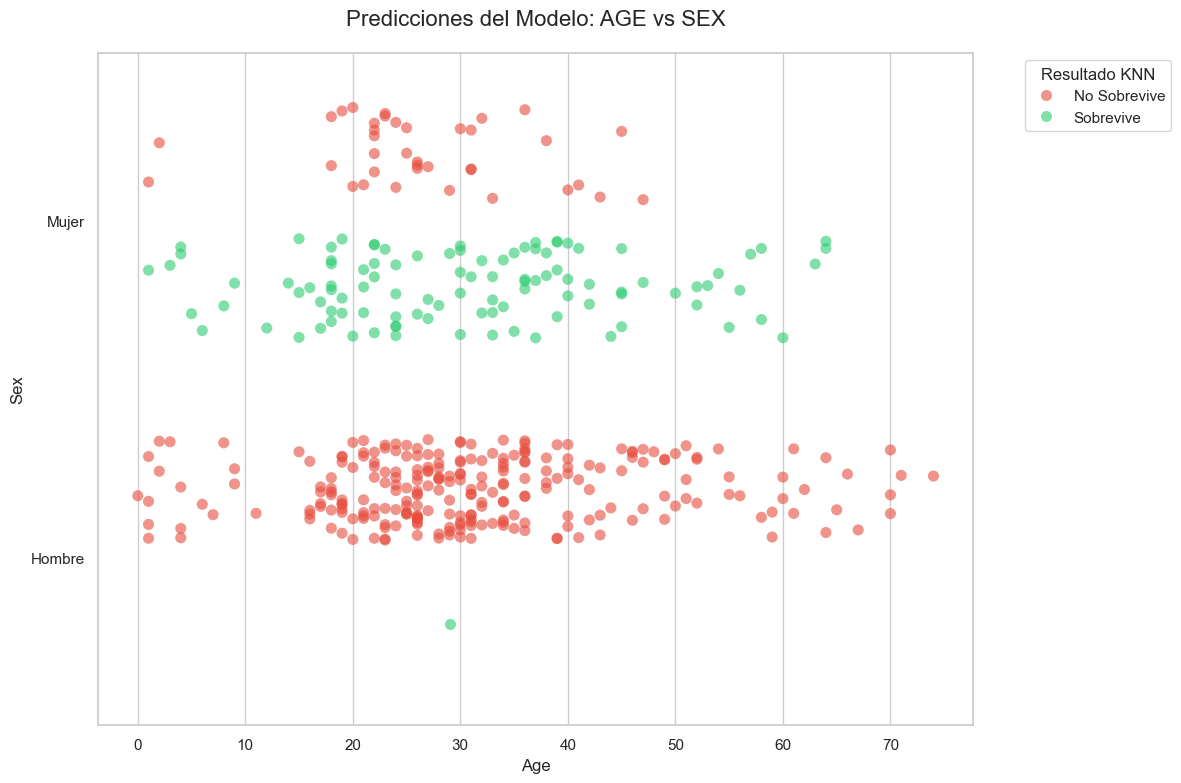

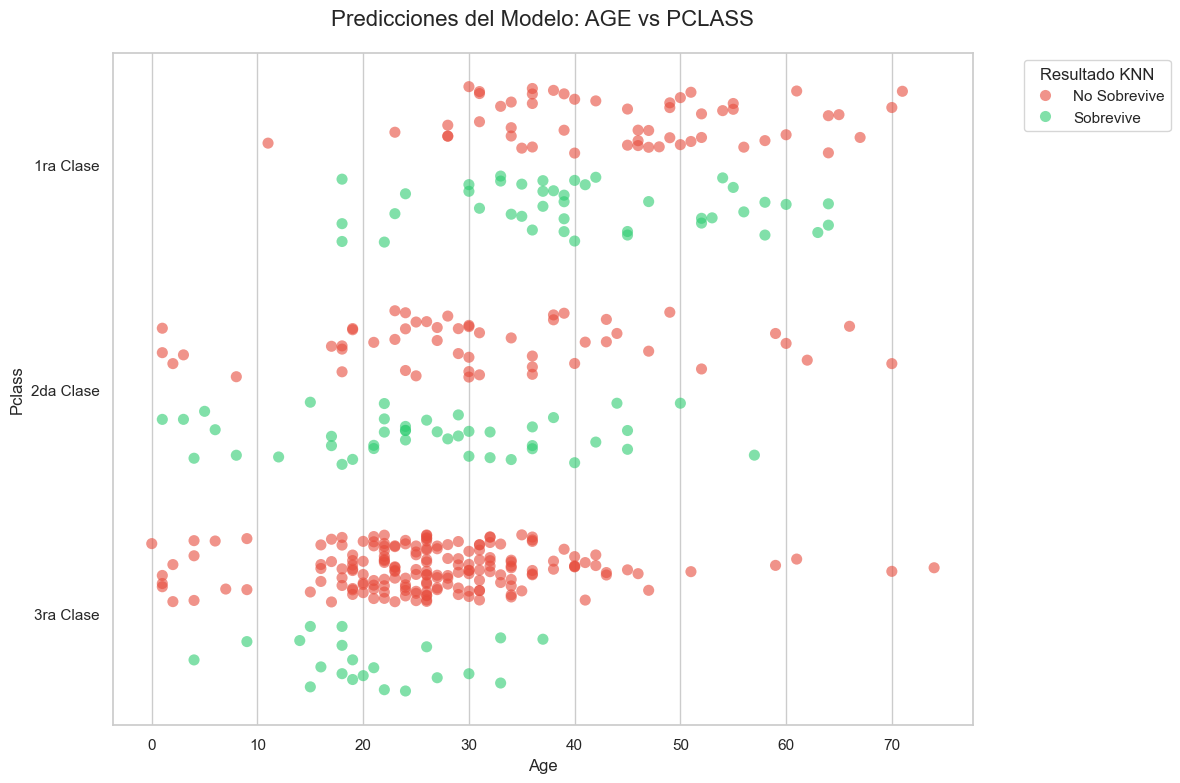

In [23]:
graficar_seaborn(dataset_Copia, X_test_indices, pred_i, 'age', 'sex')
graficar_seaborn(dataset_Copia, X_test_indices, pred_i, 'age', 'pclass')

## Entrenamiento KNN usando K-Fold

In [25]:
def validacion_k_fold_retornar_modelo(df, objetivo, k_folds=5, k_vecinos=5):
    indices = df.index.tolist()
    np.random.seed(42)
    np.random.shuffle(indices)
    
    folds_indices = np.array_split(indices, k_folds)
    
    mejor_accuracy = 0
    mejor_modelo = None
    mejores_indices_test = None
    lista_accuracy = []

    for i in range(k_folds):
        indices_test = folds_indices[i]
        indices_train = np.concatenate([folds_indices[j] for j in range(k_folds) if j != i])
        
        # Separación de datos
        train_df = df.loc[indices_train]
        test_df = df.loc[indices_test]
        
        X_train = train_df.drop(columns=[objetivo]).values
        Y_train = train_df[objetivo].values
        X_test = test_df.drop(columns=[objetivo]).values
        Y_test = test_df[objetivo].values
        
        # Entrenar modelo
        modelo_actual = KNeighbors_Classifier(k=k_vecinos)
        modelo_actual.fit(X_train, Y_train)
        
        # Validar
        predicciones = modelo_actual.predict(X_test)
        accuracy_actual = np.mean(predicciones == Y_test)
        lista_accuracy.append(accuracy_actual)
        
        # GUARDAR EL MEJOR
        if accuracy_actual > mejor_accuracy:
            mejor_accuracy = accuracy_actual
            mejor_modelo = modelo_actual
            mejores_indices_test = indices_test
            
        print(f"Fold {i+1}: Accuracy = {accuracy_actual:.4f}")

    print(f"\n---> Validación finalizada. Promedio: {np.mean(lista_accuracy):.4f}")
    print(f"---> Mejor Accuracy detectado: {mejor_accuracy:.4f}")
    
    # Retornamos el mejor modelo y sus datos de prueba para tus métricas
    return mejor_modelo, mejores_indices_test, lista_accuracy

In [30]:
mejor_knn3, indices_para_metricas3, todos_los_scores3 = validacion_k_fold_retornar_modelo(dataset_Normalizado, 'survived',3,5)
print("\n" + "="*50 + "\n")
mejor_knn5, indices_para_metricas5, todos_los_scores5 = validacion_k_fold_retornar_modelo(dataset_Normalizado, 'survived',5,5)
print("\n" + "="*50 + "\n")
mejor_knn7, indices_para_metricas7, todos_los_scores7 = validacion_k_fold_retornar_modelo(dataset_Normalizado, 'survived',7,5)
print("\n" + "="*50 + "\n")
mejor_knn10, indices_para_metricas10, todos_los_scores10 = validacion_k_fold_retornar_modelo(dataset_Normalizado, 'survived',10,5)


Fold 1: Accuracy = 0.7780
Fold 2: Accuracy = 0.7661
Fold 3: Accuracy = 0.7683

---> Validación finalizada. Promedio: 0.7708
---> Mejor Accuracy detectado: 0.7780


Fold 1: Accuracy = 0.7519
Fold 2: Accuracy = 0.8053
Fold 3: Accuracy = 0.8168
Fold 4: Accuracy = 0.7786
Fold 5: Accuracy = 0.7241

---> Validación finalizada. Promedio: 0.7754
---> Mejor Accuracy detectado: 0.8168


Fold 1: Accuracy = 0.7647
Fold 2: Accuracy = 0.7754
Fold 3: Accuracy = 0.7807
Fold 4: Accuracy = 0.8128
Fold 5: Accuracy = 0.7861
Fold 6: Accuracy = 0.7380
Fold 7: Accuracy = 0.7273

---> Validación finalizada. Promedio: 0.7693
---> Mejor Accuracy detectado: 0.8128


Fold 1: Accuracy = 0.7710
Fold 2: Accuracy = 0.7328
Fold 3: Accuracy = 0.8244
Fold 4: Accuracy = 0.7710
Fold 5: Accuracy = 0.7939
Fold 6: Accuracy = 0.8168
Fold 7: Accuracy = 0.7863
Fold 8: Accuracy = 0.7328
Fold 9: Accuracy = 0.7176
Fold 10: Accuracy = 0.7538

---> Validación finalizada. Promedio: 0.7700
---> Mejor Accuracy detectado: 0.8244


### Pruebas con 5 k-folds

In [51]:
def graficar_heatmap_sobrevivencia(df_original, test_indices, Y_pred):
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="white")

    # 1. Preparar datos
    df_plot = df_original.loc[test_indices].copy()
    df_plot['Prediccion'] = Y_pred # 1 para sobrevive, 0 para muere
    
    # Mapear nombres
    df_plot['sex'] = df_plot['sex'].map({0: 'Mujer', 1: 'Hombre'})
    df_plot['pclass'] = df_plot['pclass'].map({1: '1ra Clase', 2: '2da Clase', 3: '3ra Clase'})

    # 2. Crear una tabla pivote con el promedio de sobrevivencia
    # El promedio de 0s y 1s nos da la tasa (ej. 0.9 = 90% de sobrevivencia)
    tabla_pivote = df_plot.pivot_table(index='sex', columns='pclass', values='Prediccion', aggfunc='mean')
    
    # Reordenar columnas para que salgan 1, 2, 3
    tabla_pivote = tabla_pivote[['1ra Clase', '2da Clase', '3ra Clase']]

    # 3. Dibujar el Heatmap
    sns.heatmap(tabla_pivote, annot=True, fmt=".1%", cmap="RdYlGn", cbar_kws={'label': 'Tasa de Sobrevivencia'})

    plt.title('Probabilidad de Sobrevivencia por Sexo y Clase (Predicciones KNN)', fontsize=15, pad=20)
    plt.xlabel('Clase Social')
    plt.ylabel('Género')
    plt.show()

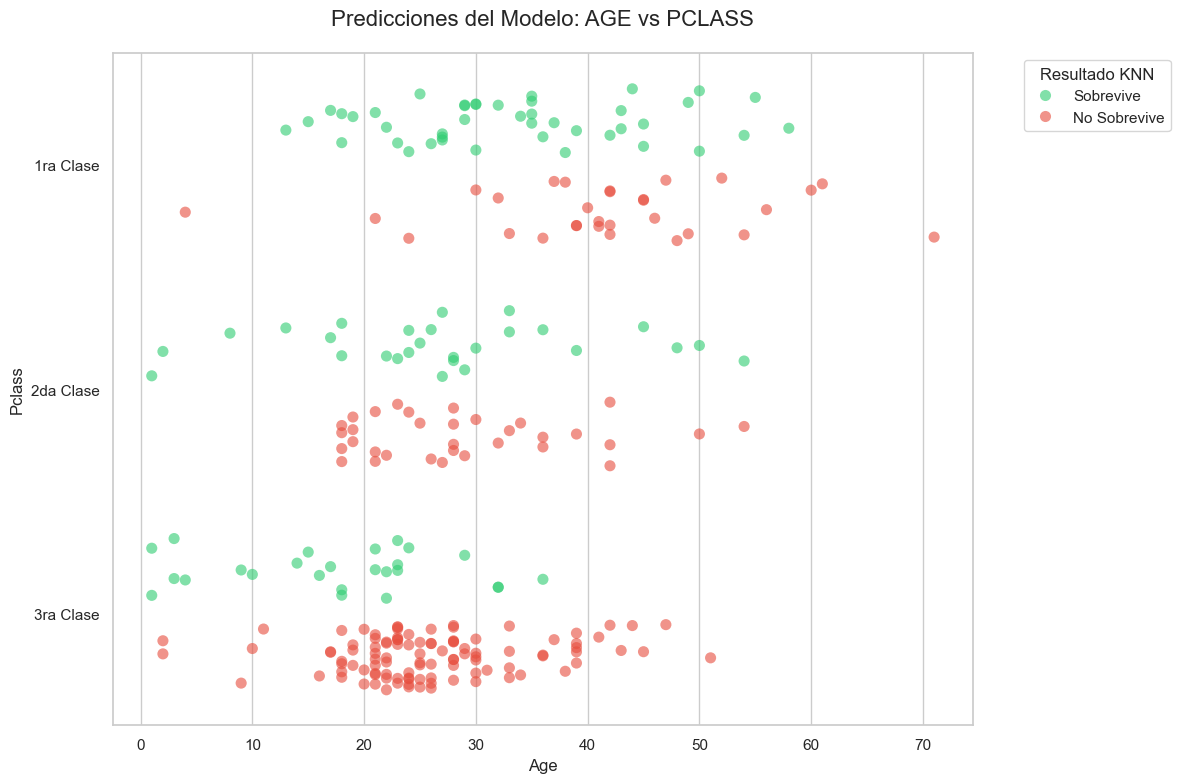

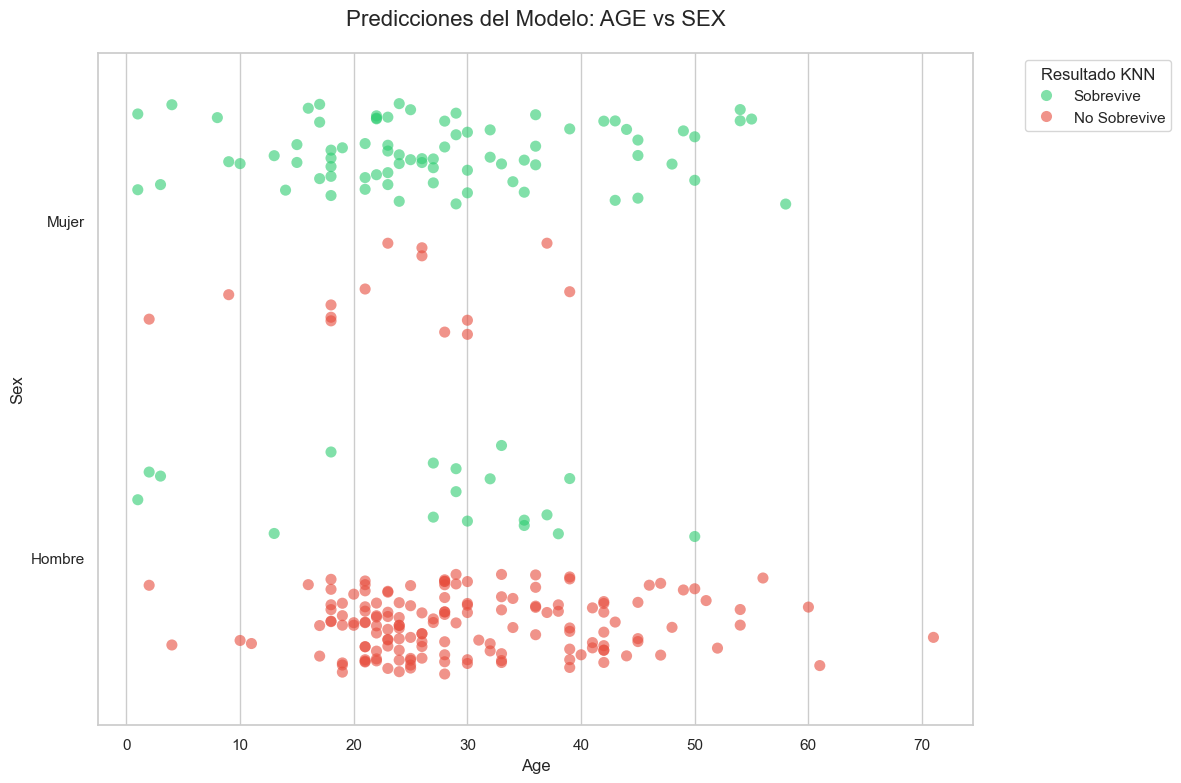

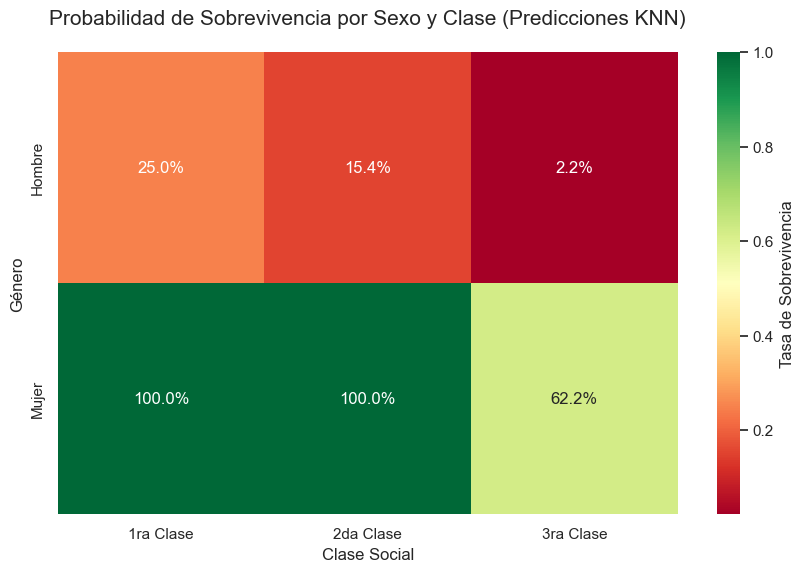

In [52]:
X_test_final5 = dataset_Normalizado.loc[indices_para_metricas5].drop(columns=['survived']).values
Y_test_final5 = dataset_Normalizado.loc[indices_para_metricas5]['survived'].values

predicciones_finales5 =  mejor_knn5.predict(X_test_final5)

# Usas el mismo modelo y los índices para que la gráfica coincida con los datos
graficar_seaborn(dataset_Copia, indices_para_metricas5, predicciones_finales5, 'age', 'pclass')
graficar_seaborn(dataset_Copia, indices_para_metricas5, predicciones_finales5, 'age', 'sex')

graficar_heatmap_sobrevivencia(dataset_Copia, indices_para_metricas5, predicciones_finales5)

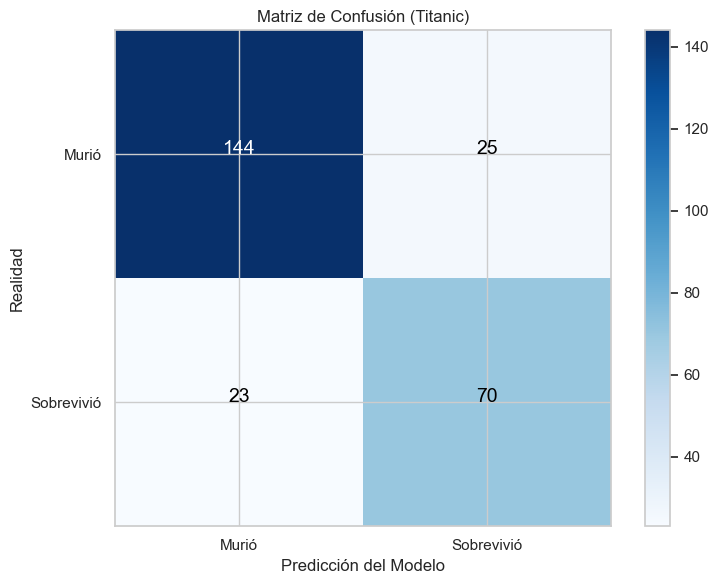

In [35]:
mi_matriz_kfold10 = calcular_matriz_confusion(Y_test_final5, predicciones_finales5)
graficar_matriz(mi_matriz_kfold10)

### Pruebas con 10 k-folds

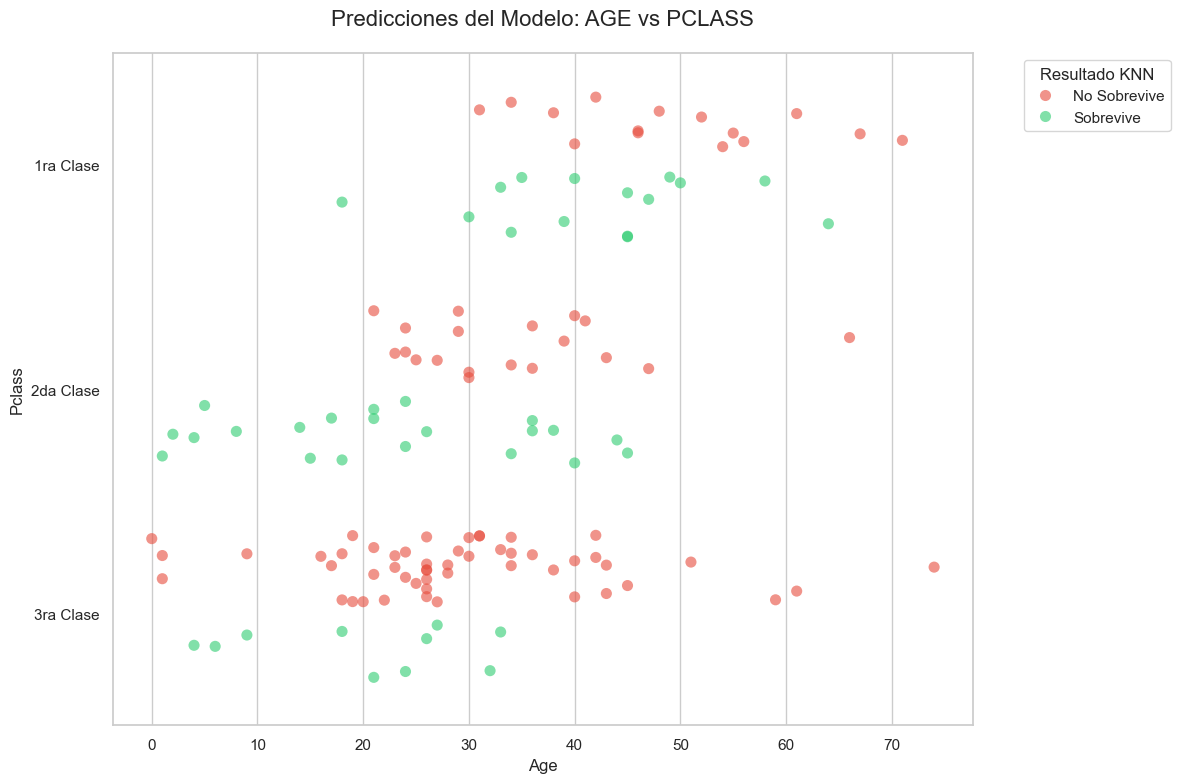

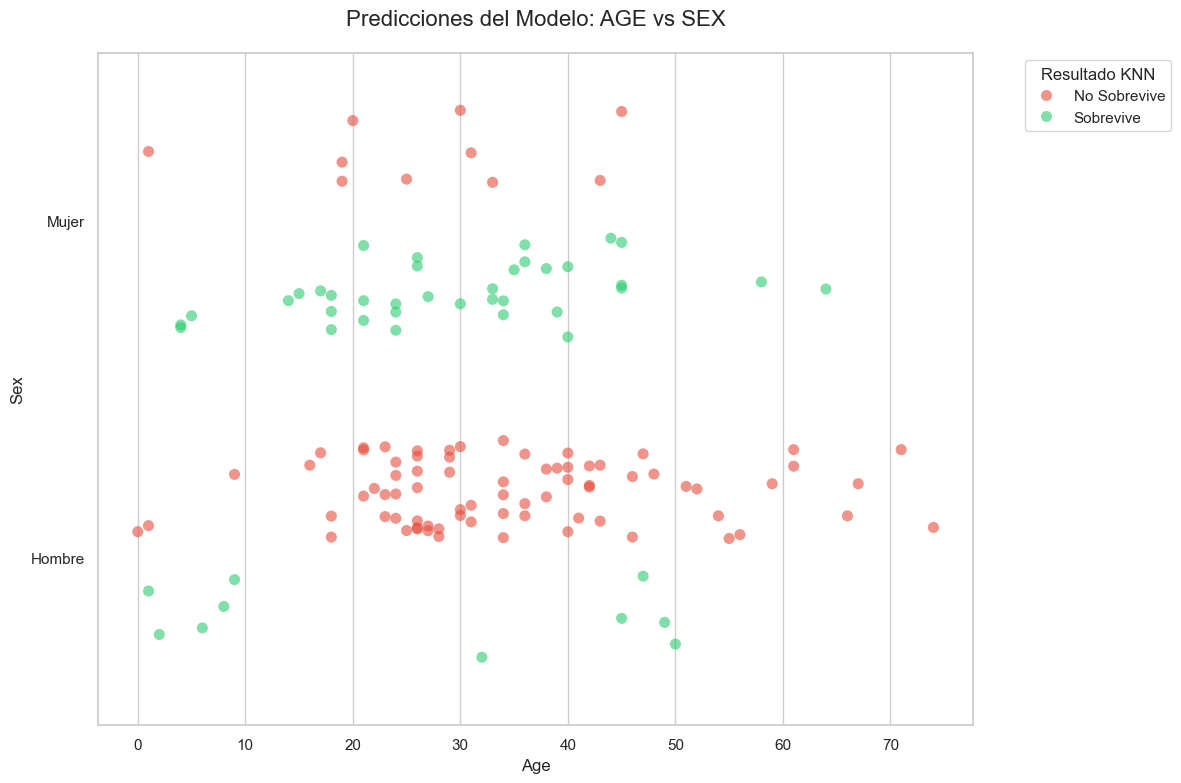

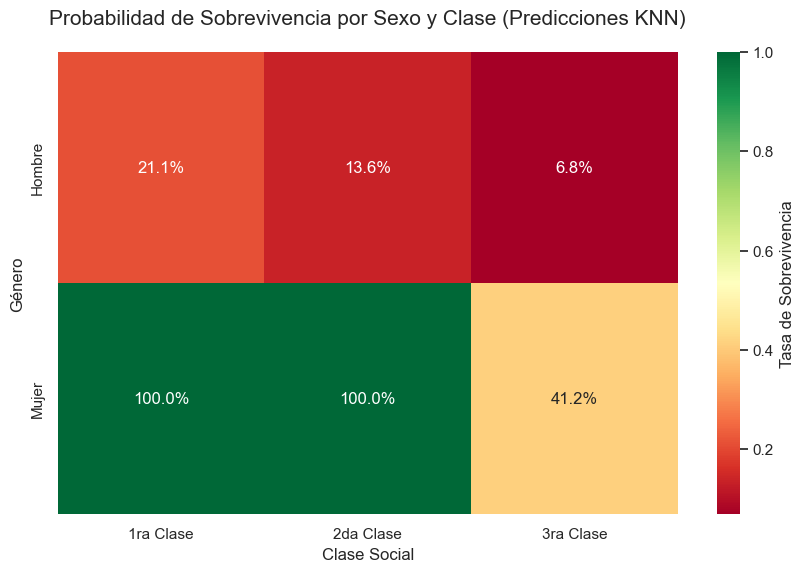

In [53]:
X_test_final10 = dataset_Normalizado.loc[indices_para_metricas10].drop(columns=['survived']).values
Y_test_final10 = dataset_Normalizado.loc[indices_para_metricas10]['survived'].values

predicciones_finales10 =  mejor_knn10.predict(X_test_final10)

# Usas el mismo modelo y los índices para que la gráfica coincida con los datos
graficar_seaborn(dataset_Copia, indices_para_metricas10, predicciones_finales10, 'age', 'pclass')
graficar_seaborn(dataset_Copia, indices_para_metricas10, predicciones_finales10, 'age', 'sex')

graficar_heatmap_sobrevivencia(dataset_Copia, indices_para_metricas10, predicciones_finales10)

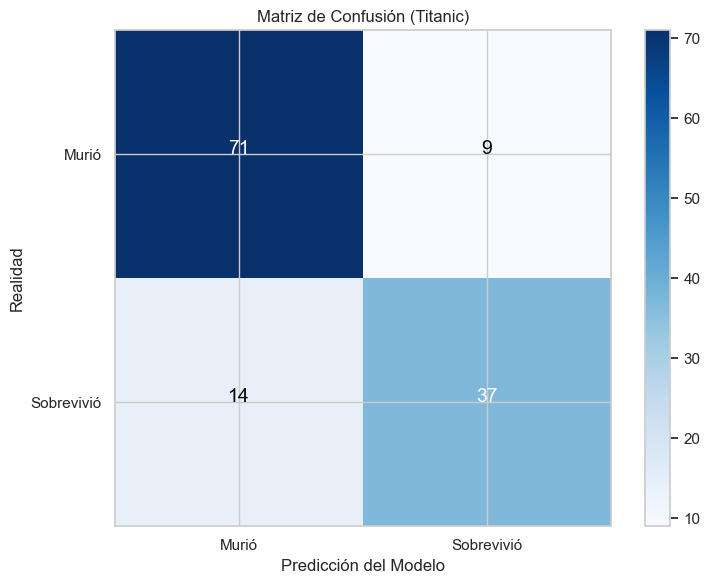

In [ ]:
mi_matriz_kfold10 = calcular_matriz_confusion(Y_test_final10, predicciones_finales10)
graficar_matriz(mi_matriz_kfold10)